In [ ]:
# Instalación de librerías requeridas
#!pip install -q diffusers transformers torch accelerate pillow

import torch

# Comprobación de disponibilidad de GPU
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo asignado: {torch.cuda.get_device_name(0)}")
else:
    print("ADVERTENCIA: No estás usando una GPU. La generación será muy lenta.")

CUDA disponible: True
Dispositivo asignado: Tesla T4


Directorios 'custom_dataset' y 'output_images' listos.
Imagen base descargada y guardada. Muestra de la imagen base:


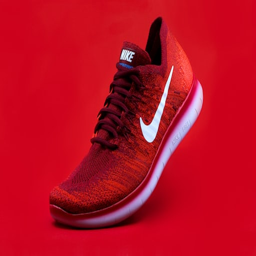

In [2]:
import os
import requests
from io import BytesIO
from PIL import Image
from IPython.display import display

# Crear directorios
dataset_dir = "custom_dataset"
output_dir = "output_images"
os.makedirs(dataset_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
print(f"Directorios '{dataset_dir}' y '{output_dir}' listos.")

# NOTA: Aquí deberías subir manualmente tus 10 imágenes a la carpeta 'custom_dataset'.
# Para garantizar que el código funcione, descargaremos una imagen de referencia temporal:
img_url = "https://images.unsplash.com/photo-1542291026-7eec264c27ff?q=80&w=512&auto=format&fit=crop"
response = requests.get(img_url)
base_image = Image.open(BytesIO(response.content)).convert("RGB")

# Guardamos la imagen de referencia
base_image_path = os.path.join(dataset_dir, "sneaker_base.jpg")
base_image.save(base_image_path)
print("Imagen base descargada y guardada. Muestra de la imagen base:")

# Mostramos un preview usando display()
display(base_image.resize((256, 256)))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

scheduler_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

Cargando el modelo Text-to-Image en GPU. Esto puede tardar unos momentos...


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando imagen para el prompt: 'A high-resolution product photo of modern running sneakers on a white background, highly detailed, professional studio lighting'...


  0%|          | 0/40 [00:00<?, ?it/s]

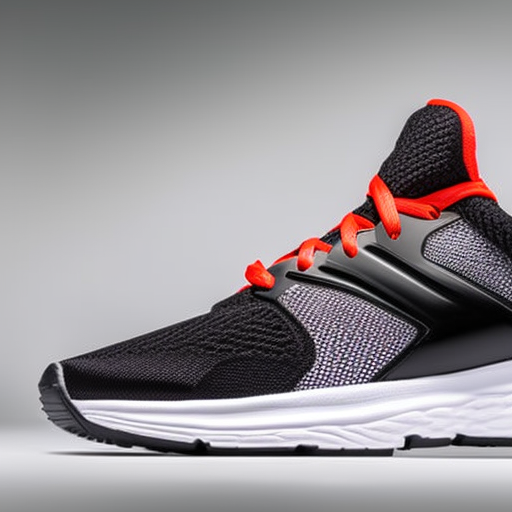

Imagen Text-to-Image guardada en: output_images/sneaker_t2i_generated.png


In [ ]:
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
import torch

# 1. Cargar modelo y scheduler (Euler Ancestral)
model_id = "stabilityai/stable-diffusion-2-1-base"
scheduler = EulerAncestralDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")

print("Cargando el modelo Text-to-Image en GPU. Esto puede tardar unos momentos...")
pipe_t2i = StableDiffusionPipeline.from_pretrained(
    model_id,
    scheduler=scheduler,
    torch_dtype=torch.float16 # Ahorra VRAM y optimiza velocidad en GPU
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe_t2i = pipe_t2i.to(device)

# 2. Configurar el prompt
prompt = "A high-resolution product photo of modern running sneakers on a white background, highly detailed, professional studio lighting"
negative_prompt = "blurry, low quality, distorted, bad proportions"

print(f"Generando imagen para el prompt: '{prompt}'...")

# 3. Generar la imagen experimentando con los parámetros
image_t2i = pipe_t2i(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=40, # Más pasos = mejor calidad, pero tarda más
    guidance_scale=8.0      # Qué tanto respeta el prompt el modelo (7.5 - 8.5 es el punto dulce)
).images[0]

# 4. Mostrar y guardar
display(image_t2i)
output_path_t2i = f"{output_dir}/sneaker_t2i_generated.png"
image_t2i.save(output_path_t2i)
print(f"Imagen Text-to-Image guardada en: {output_path_t2i}")

Configurando el modelo Image-to-Image...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Aplicando variaciones con el prompt: 'A futuristic cyberpunk version of the product with glowing neon accents and a dark sci-fi background, 8k resolution'...


  0%|          | 0/40 [00:00<?, ?it/s]

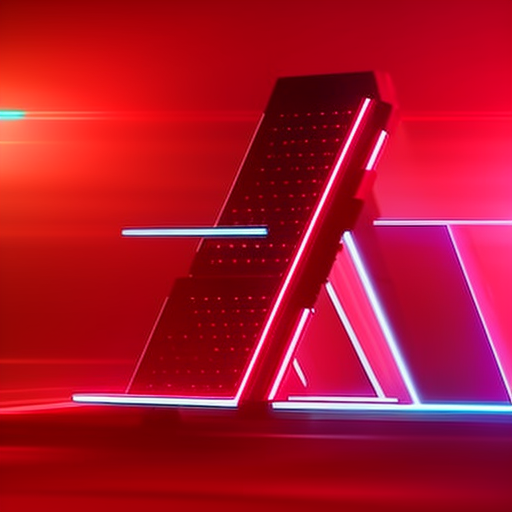

Variación Image-to-Image guardada en: output_images/sneaker_i2i_variation.png


In [5]:
from diffusers import StableDiffusionImg2ImgPipeline, DPMSolverMultistepScheduler
from PIL import Image

# 1. Cargar el pipeline de Image-to-Image reutilizando el modelo
print("Configurando el modelo Image-to-Image...")
pipe_i2i = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to(device)

# Cambiamos el Scheduler como pide el ejercicio para ver cómo influye
pipe_i2i.scheduler = DPMSolverMultistepScheduler.from_config(pipe_i2i.scheduler.config)

# 2. Cargar y preparar la imagen base
init_image = Image.open(f"{dataset_dir}/sneaker_base.jpg").convert("RGB")
init_image = init_image.resize((512, 512)) # Estandarizamos resolución para SD 2.1

# 3. Prompt para la variación
prompt_i2i = "A futuristic cyberpunk version of the product with glowing neon accents and a dark sci-fi background, 8k resolution"
negative_prompt_i2i = "ugly, messy, deformed, lowres"

print(f"Aplicando variaciones con el prompt: '{prompt_i2i}'...")

# 4. Generar variación (ajustando strength)
# Un strength de 0.8 permite cambios bastante radicales. Si pones 0.3, se parecerá mucho a la original.
image_variation = pipe_i2i(
    prompt=prompt_i2i,
    negative_prompt=negative_prompt_i2i,
    image=init_image,
    strength=0.8,            # Fuerza de la transformación (0.0 a 1.0)
    num_inference_steps=50,
    guidance_scale=8.5
).images[0]

# 5. Mostrar y guardar
display(image_variation)
output_path_i2i = f"{output_dir}/sneaker_i2i_variation.png"
image_variation.save(output_path_i2i)
print(f"Variación Image-to-Image guardada en: {output_path_i2i}")